In [1]:
import importlib.util
import os
import re
import sys
from glob import glob

import h5py
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from jax import numpy as jnp
from jax import random as jr
from scipy import linalg

In [2]:
sys.path.insert(0, os.path.abspath(".."))

In [3]:
from experiments.models import nn

## Visuzliation


In [588]:
custom_params = {
  "font.family": "serif",
  "font.weight": "light",
  "font.serif": "cmr10",
  "mathtext.fontset": "stix",
  "axes.labelsize": 14,
  "text.usetex": False,
}
sns.set_theme(style="ticks", context="paper", rc=custom_params)

## Compute metrics

In [5]:
def load_config(path):
  spec = importlib.util.spec_from_file_location("config_module", path)
  module = importlib.util.module_from_spec(spec)
  spec.loader.exec_module(module)
  return module.get_config()

In [737]:
def ddm_model(config_file, model):
  inputs = jnp.ones((1, 32, 32, 8))
  times = jnp.ones(1)
  cond = jnp.ones((1, 8))

  variables = model.init(jr.key(0), inputs, times, inputs, cond, False)
  jit_fwd = jax.jit(
    lambda inputs, times, cond: model.apply(
      variables, inputs, times, inputs, cond, False
    )
  )
  compiled = jit_fwd.lower(inputs, times, cond).compile()
  cost = compiled.cost_analysis()
  return config_file, model, cost[0]["flops"] / 10**9


def wgan_model(config_file, model):
  inputs = jnp.ones((1, 32, 32, 8))
  times = jnp.ones(1)
  cond = jnp.ones((1, 8))

  variables = model.init(jr.key(0), inputs, cond, False)
  jit_fwd = jax.jit(
    lambda inputs, cond: model.apply(
      variables, inputs, cond, False, rngs={"dropout": jr.key(1)}
    )
  )
  compiled = jit_fwd.lower(inputs, cond).compile()
  cost = compiled.cost_analysis()
  return config_file, model, cost[0]["flops"] / 10**9

In [738]:
def spectral_density(signal):
  sd = np.abs(np.fft.rfft(signal, axis=-1))
  log_sd = np.log(np.clip(sd, 1e-8, None))
  return log_sd


def compute_asd_fd(target, target_hat, cut=8033):
  asd_preds = spectral_density(target[:, :cut])
  asd_targets = spectral_density(target_hat[:, :cut])
  fd = frechet_distance(asd_preds, asd_targets, isotropic=True)
  return fd


def compute_asd_fd_per_label(
  waveforms, distance_bins, magnitude_bins, cut=8033
):
  mag, dist = get_magnitudes_and_distances(waveforms)
  all_results = {}
  for c in range(3):
    results = []
    for i in range(len(distance_bins) - 1):
      results.append([])
      for j in range(len(magnitude_bins) - 1):
        mask = (dist >= distance_bins[i]) & (dist < distance_bins[i + 1])
        mask &= (mag >= magnitude_bins[j]) & (mag < magnitude_bins[j + 1])
        try:
          fid = compute_asd_fd(
            waveforms["target_hat"][mask, :cut, c],
            waveforms["target"][mask, :cut, c],
          )
        except Exception:
          fid = np.nan
        results[i].append(fid)
    all_results[c] = results
  return all_results

In [739]:
def get_magnitudes_and_distances(waveforms):
  meta = waveforms["meta"][:]
  magnitudes = meta[:, 0]
  distances = jnp.sqrt(
    jnp.square(meta[:, 6] - meta[:, 2])
    + jnp.square(meta[:, 7] - meta[:, 3])
    + jnp.square(meta[:, 5] - meta[:, 4] * 1e-3)
  )
  return magnitudes, distances


def frechet_distance(x: np.ndarray, y: np.ndarray, isotropic=False, eps=1e-6):
  mu_x = np.nanmean(x, axis=0)
  mu_y = np.nanmean(y, axis=0)

  if isotropic:
    std_x = np.nanstd(x, axis=0)
    std_y = np.nanstd(y, axis=0)
    return np.sum((mu_x - mu_y) ** 2) + np.sum((std_x - std_y) ** 2)

  cov_x = np.cov(x, rowvar=False)
  cov_y = np.cov(y, rowvar=False)

  covmean, _ = linalg.sqrtm(cov_x @ cov_y, disp=False)
  if not np.isfinite(covmean).all():
    print(
      f"fid calculation produces singular product; adding {eps} to diagonal of cov estimates"
    )
    offset = np.eye(cov_x.shape[0]) * eps
    covmean = linalg.sqrtm((cov_x + offset) @ (cov_y + offset))

  # Numerical error might give slight imaginary component
  if np.iscomplexobj(covmean):
    if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
      raise ValueError(f"Imaginary component {np.max(np.abs(covmean.imag))}")
    covmean = covmean.real

  return (
    np.sum((mu_x - mu_y) ** 2)
    + np.trace(cov_x)
    + np.trace(cov_y)
    - 2 * np.trace(covmean)
  )


def compute_fid(target_hat_embedding, target_embedding):
  fid = frechet_distance(
    target_hat_embedding, target_embedding, isotropic=False
  )
  return fid


def compute_fid_per_label(waveforms, mag_bins, dist_bins):
  mag, dist = get_magnitudes_and_distances(waveforms)
  results = []
  for i in range(len(dist_bins) - 1):
    results.append([])
    for j in range(len(mag_bins) - 1):
      mask = (dist >= dist_bins[i]) & (dist < dist_bins[i + 1])
      mask &= (mag >= mag_bins[j]) & (mag < mag_bins[j + 1])
      try:
        fid = compute_fid(
          waveforms["target_hat_classifier_embedding"][mask],
          waveforms["target_classifier_embedding"][mask],
        )
      except Exception:
        fid = np.nan
      results[i].append(fid)
  return results

In [740]:
distance_bins = [0.0, 25.0, 50.0, 75.0, 125.0]
magnitude_bins = [1.0, 2.0, 2.5, 3.5, 4.5, 6.6]

In [741]:
config_files = glob("../configs/*py")

gflops = {}
for config_file in config_files:
  config = load_config(config_file)
  if "dit" in config_file:
    model = nn.dit.make_model(config.model.nn.dit_score_net)
    cfg, model, cost = ddm_model(config_file, model)
  elif "unet" in config_file:
    model = nn.unet.make_model(config.model.nn.unet_score_net)
    cfg, model, cost = ddm_model(config_file, model)
  elif "wgan" in config_file:
    model, _ = nn.gan_pix2pix.make_models(config.model.nn)
    cfg, model, cost = wgan_model(config_file, model)
  else:
    continue
  gflops[cfg] = cost

In [13]:
reg = re.compile("^.*evaluation-(.*)-small_ae.h5$")
fid_files = glob("../../../results/workdir/outputs/eval*h5")

fids = {}
for file in sorted(fid_files):
  model_name = reg.match(file).group(1)
  with h5py.File(file, "r") as test_waveforms:
    fids[file] = compute_fid_per_label(
      test_waveforms, magnitude_bins, distance_bins
    )

/var/folders/w8/7mc8k9m916qgh982xqxfgsr00000gn/T/ipykernel_47251/83664296.py:23: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_x @ cov_y, disp=False)
/var/folders/w8/7mc8k9m916qgh982xqxfgsr00000gn/T/ipykernel_47251/83664296.py:23: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(cov_x @ cov_y, disp=False)


In [20]:
reg = re.compile("^.*evaluation-(.*)-small_ae.h5$")
asd_files = glob("../../../results/workdir/outputs/eval*h5")

asds = {}
for file in sorted(asd_files):
  model_name = reg.match(file).group(1)
  with h5py.File(file, "r") as test_waveforms:
    asds[file] = compute_asd_fd_per_label(
      test_waveforms, distance_bins=distance_bins, magnitude_bins=magnitude_bins
    )

## Compute scatter plots

In [41]:
models_nice = {
  "ddm-dit-fm": "FM (DiT)",
  "ddm-unet-fm": "FM (UNet)",
  "ddm-dit-edm": "EDM (DiT)",
  "ddm-unet-edm": "EDM (UNet)",
  "ddm-dit_patch_8-fm": "FM (DiT 8x8)",
  "ddm-dit_patch_4-fm": "FM (DiT 4x4)",
  "ddm-dit_small-fm": "FM (small DiT)",
  "ddm-dit_large-fm": "FM (large DiT)",
  "wgan-pix2pix": "WGAN-GP (pix2pix)",
  "cd-dit-edm": "CM (DiT)",
}

In [721]:
model_nfe = {
  "ddm-dit-fm": 25,
  "ddm-unet-fm": 25,
  "ddm-unet-edm": 50,
  "ddm-dit-edm": 50,
  "ddm-dit_patch_8-fm": 25,
  "ddm-dit_patch_4-fm": 25,
  "ddm-dit_small-fm": 25,
  "ddm-dit_large-fm": 25,
  "wgan-pix2pix": 1,
  "cd-dit-edm": 2,
}

In [426]:
from matplotlib.patches import Patch

In [745]:
float_formatter = "{:.2f}".format
np.set_printoptions(formatter={"float_kind": float_formatter})

In [749]:
asds_nice = {
  re.match(".*evaluation-(.*)-small*", k).group(1): v for k, v in asds.items()
}
fids_nice = {
  re.match(".*evaluation-(.*)-small*", k).group(1): v for k, v in fids.items()
}
gflops_nice = {
  re.match(".*config-(.*)-small*", k).group(1): float(float_formatter(v))
  for k, v in gflops.items()
}

for k, v in asds_nice.items():
  asds_nice[k] = np.nanmedian(list(v.values())[:2])
for k, v in fids_nice.items():
  fids_nice[k] = np.nanmedian(v)

In [750]:
gflops_nice

{'ddm-dit-edm': 94.43,
 'ddm-dit_small-fm': 26.15,
 'ddm-unet-edm': 31.22,
 'wgan-pix2pix': 4.06,
 'ddm-unet-fm': 31.22,
 'ddm-dit-fm': 94.43,
 'ddm-dit_patch_8-fm': 5.42,
 'cd-dit-edm': 94.43,
 'ddm-dit_large-fm': 163.35,
 'ddm-dit_patch_4-fm': 21.84}

/var/folders/w8/7mc8k9m916qgh982xqxfgsr00000gn/T/ipykernel_47251/1981800246.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))


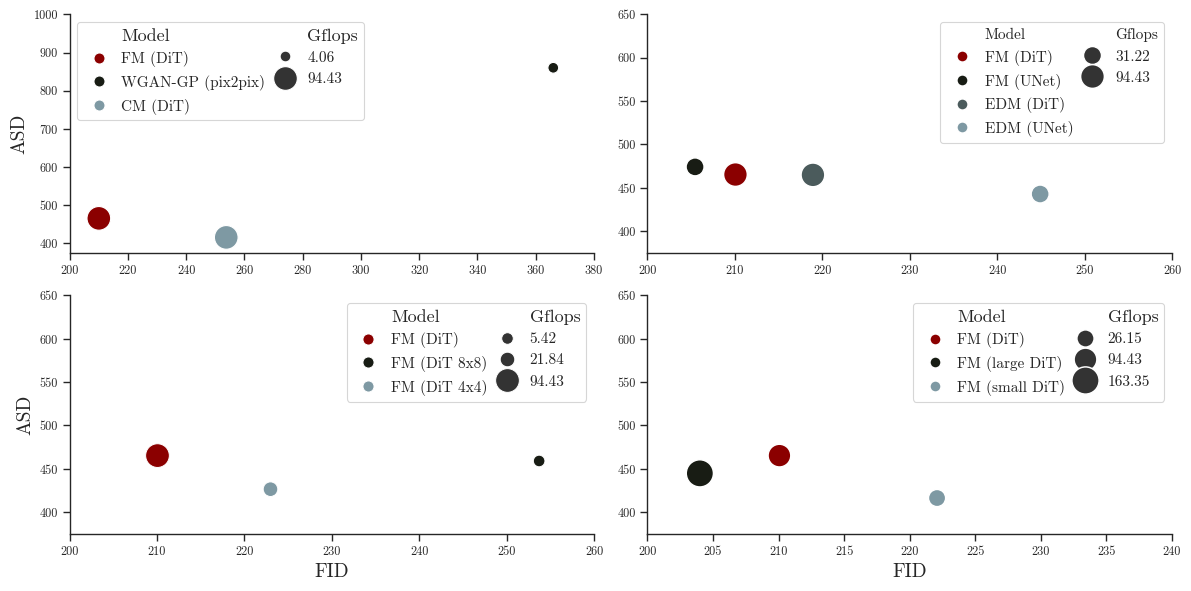

In [751]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))

##
df = pd.DataFrame(
  {
    "Model": [
      models_nice["ddm-dit-fm"],
      models_nice["wgan-pix2pix"],
      models_nice["cd-dit-edm"],
    ],
    "FID": [
      fids_nice["ddm-dit-fm"],
      fids_nice["wgan-pix2pix"],
      fids_nice["cd-dit-edm"],
    ],
    "ASD": [
      asds_nice["ddm-dit-fm"],
      asds_nice["wgan-pix2pix"],
      asds_nice["cd-dit-edm"],
    ],
    "Gflops": [
      gflops_nice["ddm-dit-fm"],
      gflops_nice["wgan-pix2pix"],
      gflops_nice["cd-dit-edm"],
    ],
  }
)

cols = sns.blend_palette(["#181C14", "#7E99A3"], n_colors=2)
dit_cols = sns.blend_palette(["#8b0000", "#b26679"], n_colors=1)
ax = sns.scatterplot(
  data=df,
  x="FID",
  y="ASD",
  size="Gflops",
  hue="Model",
  sizes=(
    np.min(np.sqrt(df["Gflops"].values)) * 30,
    np.max(np.sqrt(df["Gflops"].values) * 30),
  ),
  ax=axes[0, 0],
  palette=dit_cols + cols,
)
ax.set_xlim(200, 380)
ax.set_ylim(375, 1000)
h, l = ax.get_legend_handles_labels()
for i, col in enumerate(dit_cols + cols):
  h[i + 1].set_markersize(8)
  h[i + 1].set_markerfacecolor(col)
legend = ax.legend(
  h,
  l,
  loc=2,
  frameon=True,
  ncol=2,
  fontsize=11,
  columnspacing=0.25,
  labelspacing=0.5,
  handletextpad=0.5,
)
sns.despine(ax=ax, top=True, right=True)
texts = legend.get_texts()
texts[0].set_fontsize(13)
texts[4].set_fontsize(13)
ax.set_xlabel(None)
##
df = pd.DataFrame(
  {
    "Model": [
      models_nice["ddm-dit-fm"],
      models_nice["ddm-dit_patch_8-fm"],
      models_nice["ddm-dit_patch_4-fm"],
    ],
    "FID": [
      fids_nice["ddm-dit-fm"],
      fids_nice["ddm-dit_patch_8-fm"],
      fids_nice["ddm-dit_patch_4-fm"],
    ],
    "ASD": [
      asds_nice["ddm-dit-fm"],
      asds_nice["ddm-dit_patch_8-fm"],
      asds_nice["ddm-dit_patch_4-fm"],
    ],
    "Gflops": [
      gflops_nice["ddm-dit-fm"],
      gflops_nice["ddm-dit_patch_8-fm"],
      gflops_nice["ddm-dit_patch_4-fm"],
    ],
  }
)

cols = sns.blend_palette(["#181C14", "#7E99A3"], n_colors=2)
dit_cols = sns.blend_palette(["#8b0000", "#b26679"], n_colors=1)
ax = sns.scatterplot(
  data=df,
  x="FID",
  y="ASD",
  size="Gflops",
  hue="Model",
  sizes=(
    np.min(np.sqrt(df["Gflops"].values)) * 30,
    np.max(np.sqrt(df["Gflops"].values) * 30),
  ),
  ax=axes[1, 0],
  palette=dit_cols + cols,
)
ax.set_xlim(200, 260)
ax.set_ylim(375, 650)
h, l = ax.get_legend_handles_labels()
for i, col in enumerate(dit_cols + cols):
  h[i + 1].set_markersize(8)
  h[i + 1].set_markerfacecolor(col)
legend = ax.legend(
  h,
  l,
  loc=0,
  frameon=True,
  ncol=2,
  fontsize=11,
  columnspacing=0.25,
  labelspacing=0.5,
  handletextpad=0.5,
)
sns.despine(ax=ax, top=True, right=True)
texts = legend.get_texts()
texts[0].set_fontsize(13)
texts[4].set_fontsize(13)
##
df = pd.DataFrame(
  {
    "Model": [
      models_nice["ddm-dit-fm"],
      models_nice["ddm-unet-fm"],
      models_nice["ddm-dit-edm"],
      models_nice["ddm-unet-edm"],
    ],
    "FID": [
      fids_nice["ddm-dit-fm"],
      fids_nice["ddm-unet-fm"],
      fids_nice["ddm-dit-edm"],
      fids_nice["ddm-unet-edm"],
    ],
    "ASD": [
      asds_nice["ddm-dit-fm"],
      asds_nice["ddm-unet-fm"],
      asds_nice["ddm-dit-edm"],
      asds_nice["ddm-unet-edm"],
    ],
    "Gflops": [
      gflops_nice["ddm-dit-fm"],
      gflops_nice["ddm-unet-fm"],
      gflops_nice["ddm-dit-edm"],
      gflops_nice["ddm-unet-edm"],
    ],
  }
)

cols = sns.blend_palette(["#181C14", "#7E99A3"], n_colors=3)
dit_cols = sns.blend_palette(["#8b0000", "#b26679"], n_colors=1)
ax = sns.scatterplot(
  data=df,
  x="FID",
  y="ASD",
  size="Gflops",
  hue="Model",
  sizes=(
    np.min(np.sqrt(df["Gflops"].values)) * 30,
    np.max(np.sqrt(df["Gflops"].values) * 30),
  ),
  ax=axes[0, 1],
  palette=dit_cols + cols,
)
ax.set_xlim(200, 260)
ax.set_ylim(375, 650)

h, l = ax.get_legend_handles_labels()
for i, col in enumerate(dit_cols + cols):
  h[i + 1].set_markersize(8)
  h[i + 1].set_markerfacecolor(col)

dummy_handles = [Patch(facecolor="none", edgecolor="none")] * (4 - 2)
combined_handles = h[:4] + h[4:] + dummy_handles
combined_labels = l[:4] + l[4:] + [""] * len(dummy_handles)

# legend = ax.legend(h, l, loc=0, frameon=True, ncol=2, fontsize=11, columnspacing=0.25, labelspacing=0.5, handletextpad=0.5)
ax.legend(
  handles=combined_handles,
  labels=combined_labels,
  ncol=2,
  fontsize=11,
  columnspacing=0.25,
  labelspacing=0.5,
  handletextpad=0.5,
  title=None,
)

sns.despine(ax=ax, top=True, right=True)
texts = legend.get_texts()
texts[0].set_fontsize(13)
texts[4].set_fontsize(13)
ax.set_xlabel(None)
ax.set_ylabel(None)

df = pd.DataFrame(
  {
    "Model": [
      models_nice["ddm-dit-fm"],
      models_nice["ddm-dit_large-fm"],
      models_nice["ddm-dit_small-fm"],
    ],
    "FID": [
      fids_nice["ddm-dit-fm"],
      fids_nice["ddm-dit_large-fm"],
      fids_nice["ddm-dit_small-fm"],
    ],
    "ASD": [
      asds_nice["ddm-dit-fm"],
      asds_nice["ddm-dit_large-fm"],
      asds_nice["ddm-dit_small-fm"],
    ],
    "Gflops": [
      gflops_nice["ddm-dit-fm"],
      gflops_nice["ddm-dit_large-fm"],
      gflops_nice["ddm-dit_small-fm"],
    ],
  }
)

cols = sns.blend_palette(["#181C14", "#7E99A3"], n_colors=2)
dit_cols = sns.blend_palette(["#8b0000", "#b26679"], n_colors=1)
ax = sns.scatterplot(
  data=df,
  x="FID",
  y="ASD",
  size="Gflops",
  hue="Model",
  sizes=(
    np.min(np.sqrt(df["Gflops"].values)) * 30,
    np.max(np.sqrt(df["Gflops"].values) * 30),
  ),
  ax=axes[1, 1],
  palette=dit_cols + cols,
)
ax.set_xlim(200, 240)
ax.set_ylim(375, 650)
h, l = ax.get_legend_handles_labels()
for i, col in enumerate(dit_cols + cols):
  h[i + 1].set_markersize(8)
  h[i + 1].set_markerfacecolor(col)
legend = ax.legend(
  h,
  l,
  loc=0,
  frameon=True,
  ncol=2,
  fontsize=11,
  columnspacing=0.25,
  labelspacing=0.5,
  handletextpad=0.5,
)
texts = legend.get_texts()
texts[0].set_fontsize(13)
texts[4].set_fontsize(13)
sns.despine(ax=ax, top=True, right=True)
ax.set_ylabel(None)

plt.savefig("../../../results/workdir/figures/asd_vs_fid_vs_gflops.pdf")
plt.tight_layout()
plt.show()

# Plot runtime vs gflops

In [752]:
runtimes = {
  "cd-dit-edm": 0.10157186212018132,
  "wgan-pix2pix": 0.0034063891507685184,
  "ddm-dit-fm": 1.2944695551414043,
  "ddm-dit_small-fm": 0.549284654087387,
  "ddm-dit_large-fm": 1.9254102979321033,
  "ddm-dit_patch_4-fm": 0.29093468887731433,
  "ddm-dit_patch_8-fm": 0.10720712412148714,
  "ddm-dit-edm": 2.568292416865006,
  "ddm-unet-fm": 0.48494972102344036,
  "ddm-unet-edm": 0.925732732983306,
}
runtimes

{'cd-dit-edm': 0.10157186212018132,
 'wgan-pix2pix': 0.0034063891507685184,
 'ddm-dit-fm': 1.2944695551414043,
 'ddm-dit_small-fm': 0.549284654087387,
 'ddm-dit_large-fm': 1.9254102979321033,
 'ddm-dit_patch_4-fm': 0.29093468887731433,
 'ddm-dit_patch_8-fm': 0.10720712412148714,
 'ddm-dit-edm': 2.568292416865006,
 'ddm-unet-fm': 0.48494972102344036,
 'ddm-unet-edm': 0.925732732983306}

/Users/simon/PROJECTS/2024-highfem/src/01-gm1/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:462: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  axes = fig.subplots(nrow, ncol, **kwargs)


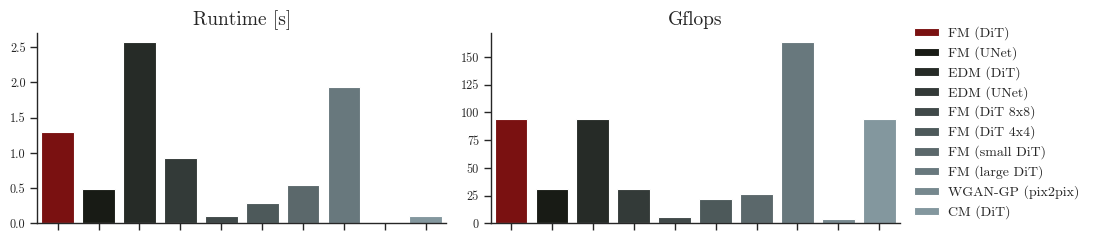

In [753]:
cols = sns.blend_palette(["#181C14", "#7E99A3"], n_colors=9).as_hex()
dit_cols = sns.blend_palette(["#8b0000", "#b26679"], n_colors=1).as_hex()


df = pd.DataFrame(
  {
    "Model": [models_nice[k] for k in models_nice.keys()],
    "Runtime [s]": [runtimes[k] for k in models_nice.keys()],
    "Gflops": [gflops_nice[k] for k in models_nice.keys()],
    # "ASD FD": [asds_nice[k] for k in  models_nice.keys()],
    "Color": dit_cols + cols,
  }
)
df = pd.melt(df, id_vars=["Model", "Color"])


g = sns.catplot(
  df,
  kind="bar",
  x="Model",
  y="value",
  col="variable",
  hue="Model",
  palette=dit_cols + cols,
  aspect=1.5,
  sharey=False,
  height=2.5,
  legend=True,
  width=0.8,
)
g.set_titles("{col_name}")
for ax in g.axes.flat:
  ax.set_xlabel(None)
  ax.tick_params(axis="x", labelsize=10)
  ax.set_ylabel(None)


g.legend.set_title(None)  # set empty string
g.legend.set_bbox_to_anchor((1.2, 0.475))  # adjust x, y as needed
g.legend.set_frame_on(False)
for t in g.legend.texts:
  t.set_fontsize(10)

for ax in g.axes.flat:
  ax.tick_params(axis="x", labelbottom=False)

plt.tight_layout()
plt.savefig(
  "../../../results/workdir/figures/gflops_vs_runtime.pdf",
  bbox_inches="tight",
)

## Table

In [771]:
res_df = pd.DataFrame(
  {
    "Model": [models_nice[k] for k in models_nice.keys()],
    "NFE": [model_nfe[k] for k in models_nice.keys()],
    "Gflops": [gflops_nice[k] for k in models_nice.keys()],
    "Runtime [s]": [runtimes[k] for k in models_nice.keys()],
    "FID": [fids_nice[k] for k in models_nice.keys()],
    "ASD FD": [asds_nice[k] for k in models_nice.keys()],
  }
)

float_formats = {
  "Runtime [s]": "{:.3f}",
  "FID": "{:.2f}",
  "ASD FD": "{:.2f}",
  "Gflops": "{:.2f}",
}


def format_col(val, col_name):
  fmt = float_formats.get(col_name, "{:.2f}")
  return np.array(fmt.format(val), dtype=np.float64) if fmt else val


for col in res_df.columns:
  if col in float_formats:
    res_df[col] = res_df[col].apply(lambda x: format_col(x, col))

In [772]:
higher_better = []
lower_better = ["FID", "ASD FD", "Runtime [s]"]


def highlight_best(s, higher=True):
  if higher:
    is_best = s == s.max()
  else:
    is_best = s == s.min()
  return [
    "\\textbf{" + str(v) + "}" if b else str(v) for v, b in zip(s, is_best)
  ]


for col in higher_better:
  res_df[col] = highlight_best(res_df[col], higher=True)
for col in lower_better:
  res_df[col] = highlight_best(res_df[col], higher=False)

In [773]:
xx = res_df.to_latex(
  index=False,
  caption="Model Performance",
  label="tab:model-performance",
  escape=False,
)
print(xx)

\begin{table}
\caption{Model Performance}
\label{tab:model-performance}
\begin{tabular}{lrrlll}
\toprule
Model & NFE & Gflops & Runtime [s] & FID & ASD FD \\
\midrule
FM (DiT) & 25 & 94.430000 & 1.294 & 210.06 & 465.27 \\
FM (UNet) & 25 & 31.220000 & 0.485 & 205.44 & 474.09 \\
EDM (DiT) & 50 & 94.430000 & 2.568 & 218.93 & 464.86 \\
EDM (UNet) & 50 & 31.220000 & 0.926 & 244.92 & 442.8 \\
FM (DiT 8x8) & 25 & 5.420000 & 0.107 & 253.72 & 459.06 \\
FM (DiT 4x4) & 25 & 21.840000 & 0.291 & 222.99 & 426.54 \\
FM (small DiT) & 25 & 26.150000 & 0.549 & 222.08 & 416.33 \\
FM (large DiT) & 25 & 163.350000 & 1.925 & \textbf{203.99} & 444.79 \\
WGAN-GP (pix2pix) & 1 & 4.060000 & \textbf{0.003} & 366.01 & 859.97 \\
CM (DiT) & 2 & 94.430000 & 0.102 & 253.79 & \textbf{415.41} \\
\bottomrule
\end{tabular}
\end{table}

